# Financial Earthquakes: Hawkes/ETAS indicator + KAN-PIN estimation

Implementation of the **"financial earthquakes"** indicator of
[Gresnigt (2020), *Identifying and Predicting Financial Earthquakes Using Hawkes Processes*](https://repub.eur.nl/pub/124777/)
(core chapter: Gresnigt, Kole & Franses 2015, *J. Banking & Finance* 56) on **AA hourly data**,
plus a **KAN-PIN** (physics-informed Kolmogorov-Arnold network, per the PINNverse and PI-KAN papers)
estimator for the model parameters.

**The idea**: extreme returns behave like earthquakes — big shocks trigger aftershocks whose frequency
decays with time (Omori's law). Model the *arrival times* of extreme returns as a marked self-exciting
(Hawkes/ETAS) point process; its conditional intensity λ(t | history) is the indicator: the expected number
of extreme events per hour, right now. From it: crash probabilities (Early Warning System), and forecasts of
**how long a fall/run episode lasts and when it ends**.

See `etas.py` (full mathematical story in the module docstring) and `README.md` (findings & conclusion).

In [1]:
from run_analysis import (load_data, fit_models, fit_cross, figure_events,
    figure_intensity, ews_out_of_sample, figure_ews, duration_forecasts,
    figure_duration, synthetic_validation, kan_pin_real, figure_kanpin,
    daily_analysis)
from IPython.display import Image, display

close_h, r_h, close_d, r_d = load_data('AA_h.csv')

1. DATA
hourly bars: 1749  (2025-07-11 -> 2026-07-10),  hourly returns: 1748
daily closes: 251,  daily returns: 250


## 1. The paper's method: extreme events → ETAS by maximum likelihood

Events = hourly returns beyond the 95% tail quantile (falls = left tail, runs = right tail), magnitudes
$m_i=|r_i|$, time on the trading clock. Four specifications (power-law vs exponential kernel × with/without
magnitude leverage α) are fit by MLE and ranked by AIC; specification is verified by the time-rescaling
KS test (rescaled inter-event times must be i.i.d. Exp(1)).

In [2]:
falls, runs, best, tables = fit_models(r_h)


2. THE PAPER'S METHOD: extreme-return events + ETAS by MLE
fall events (r <= -0.0165): 88
run  events (r >= +0.0178): 88



--- FALL variants (AIC-ranked):
          model      logL      AIC     mu     K0   alpha        c  branching_n  KS_pvalue
  exp (alpha=0) -350.7839 707.5679 0.0419 0.1789  0.0000  79.1198       0.1789     0.3813
power (alpha=0) -349.9632 707.9264 0.0353 0.9950  0.0000 174.8000       0.9950     0.7114
            exp -350.6928 709.3855 0.0411 0.1609  9.6683  79.1295       0.1954     0.4007
          power -349.9155 709.8310 0.0360 0.9950 15.6609 174.8000       1.3942     0.6348

ETAS model for FALL events (exp kernel, alpha=0):
  Data: 88 extreme negative returns (|r| >= 0.0165) over 1748 periods -> unconditional rate 0.0503 events/period.
  Background rate mu = 0.0419: about one *spontaneous* fall event every 24 periods.
  Branching ratio n = 0.18: each event triggers on average 0.18 direct aftershocks (18% of all events are aftershocks in equilibrium; one spontaneous shock spawns a cluster of ~1.2 events in total).
  Aftershock decay: half of the triggering pressure is released withi


--- RUN variants (AIC-ranked):
          model      logL      AIC     mu     K0  alpha       c  branching_n  KS_pvalue
  exp (alpha=0) -351.0224 708.0448 0.0503 0.0000 0.0000 79.1163       0.0000     0.0399
            exp -351.0224 710.0448 0.0503 0.0000 2.4402 67.0825       0.0000     0.0399
power (alpha=0) -351.0224 710.0448 0.0503 0.0000 0.0000  9.1379       0.0000     0.0399
          power -350.9666 711.9333 0.0457 0.4184 2.5913 67.0886       0.4356     0.0541

ETAS model for RUN events (exp kernel, alpha=0):
  Data: 88 extreme positive returns (|r| >= 0.0178) over 1748 periods -> unconditional rate 0.0503 events/period.
  Background rate mu = 0.0503: about one *spontaneous* run event every 20 periods.
  Branching ratio n = 0.00: each event triggers on average 0.00 direct aftershocks (0% of all events are aftershocks in equilibrium; one spontaneous shock spawns a cluster of ~1.0 events in total).
  Aftershock decay: half of the triggering pressure is released within 54.8 periods

**Reading the result**: falls self-excite (branching ratio n ≈ 0.18, i.e. each extreme drop triggers
~0.18 further extreme drops, decaying with a ~55h half-life) and the model passes the KS test. Runs collapse
to Poisson (K₀ ≈ 0): crashes cascade, rallies don't. Below we also test the thesis's *cross-excitation*
(spillover) hypothesis with a bivariate mutually-exciting Hawkes — falls ⇄ runs.

In [3]:
cross = fit_cross(falls, runs)


3. CROSS-EXCITATION (falls <-> runs), bivariate Hawkes


Bivariate Hawkes (falls <-> runs), exponential kernels:
  Background rates: mu_fall = 0.0438, mu_run = 0.0503 per period.
  Branching matrix (direct offspring per event):
    fall -> fall 0.13 | run -> fall 0.00
    fall -> run  0.00 | run -> run  0.00
  Spectral radius = 0.13 (< 1: stationary).
  Decay half-lives into falls: from falls 37, from runs 5 periods;
  into runs: from falls 38, from runs 5 periods.
LR test of no cross-excitation into fall: LR=-0.00, p=1.000


LR test of no cross-excitation into run: LR=0.00, p=1.000


saved figures/fig1_price_events.png


saved figures/fig2_intensity.png


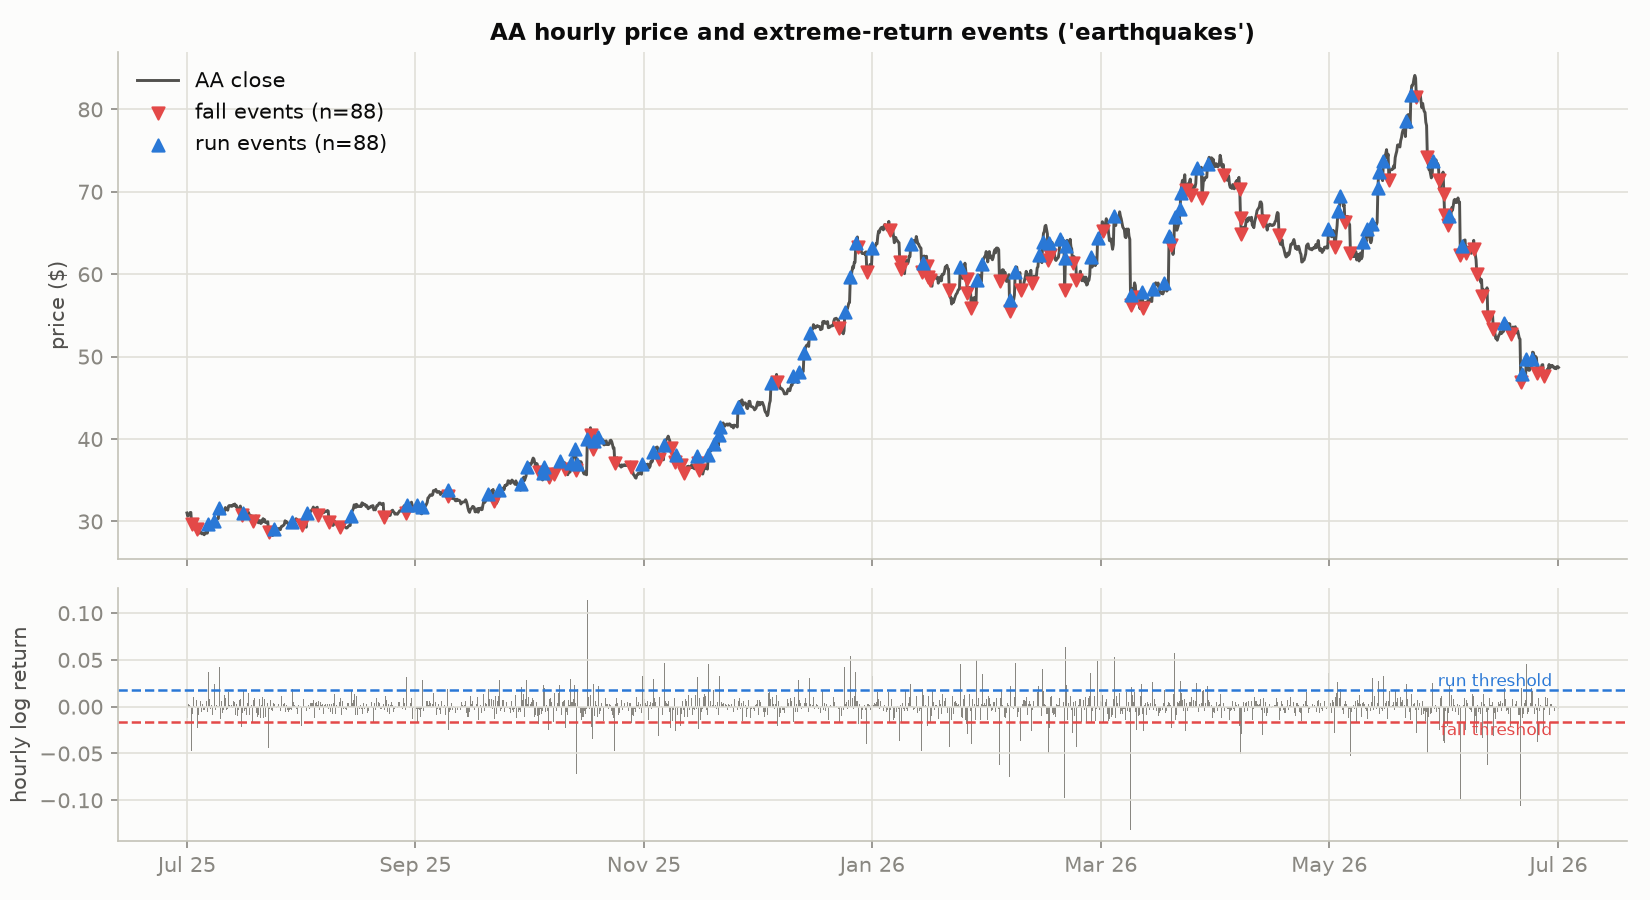

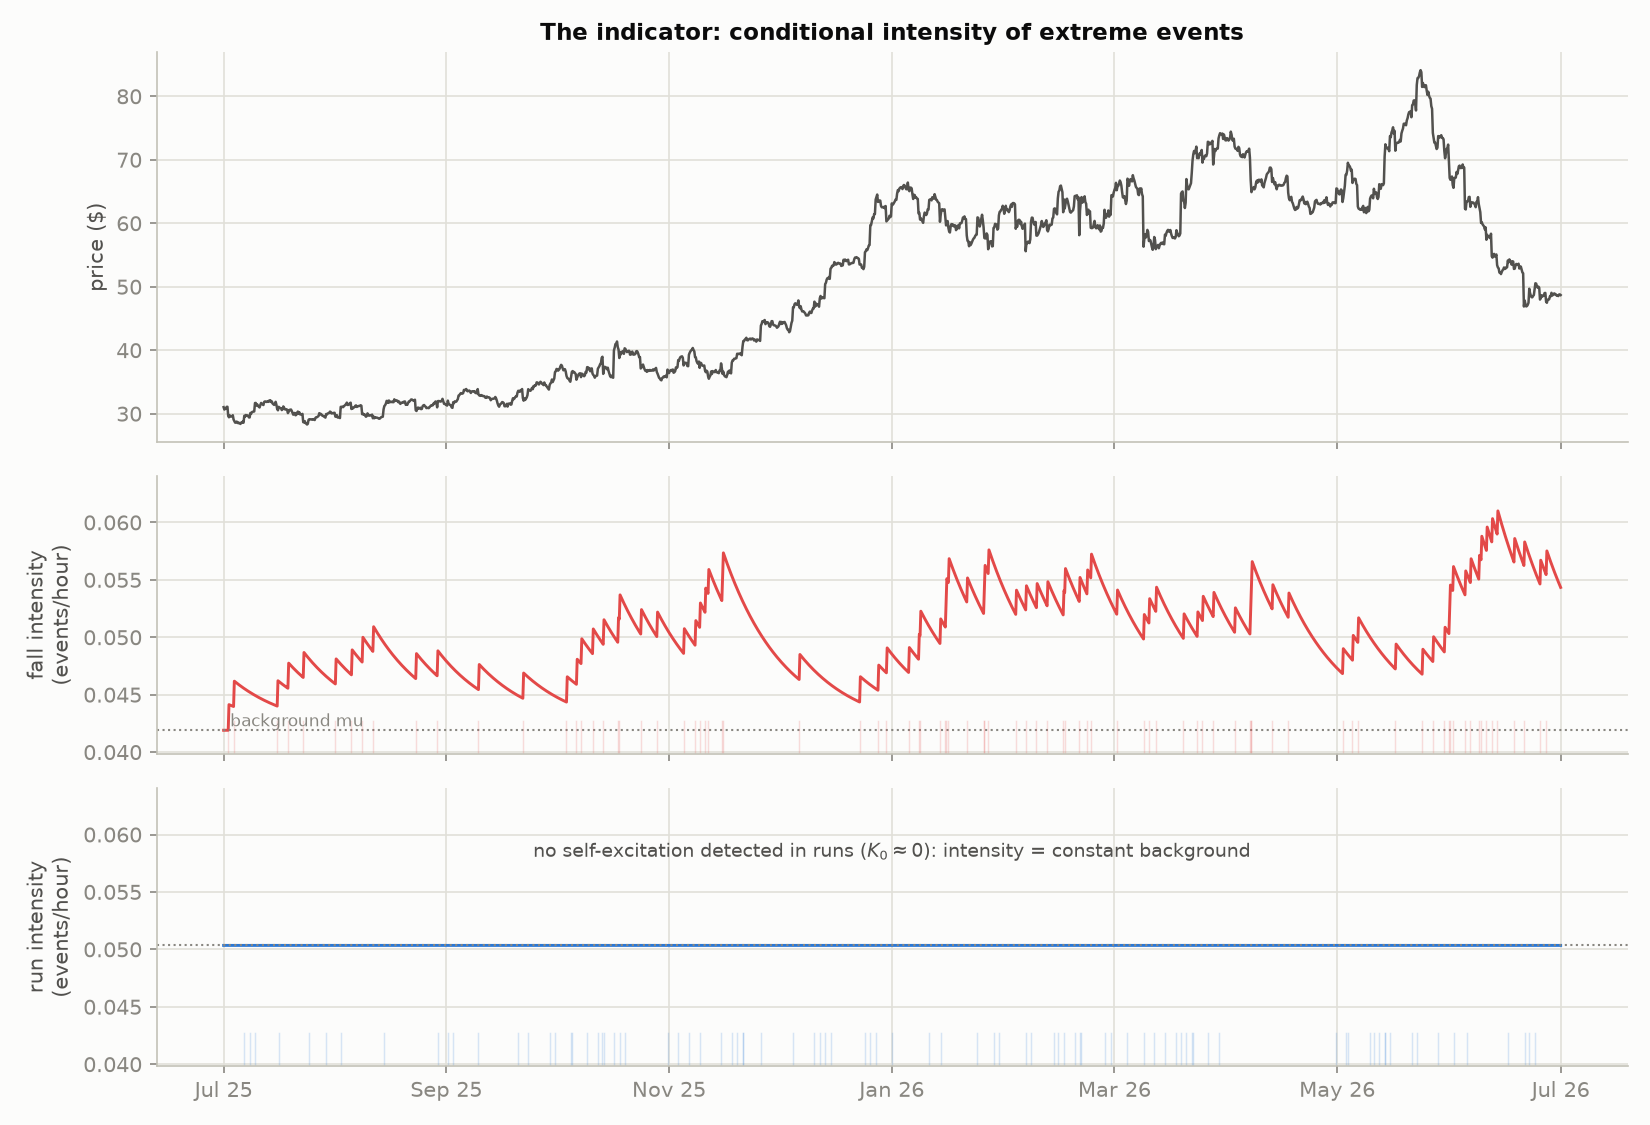

In [4]:
figure_events(close_h, r_h, falls, runs)
figure_intensity(close_h, r_h, best)
display(Image('figures/fig1_price_events.png'), Image('figures/fig2_intensity.png'))

## 2. Early Warning System (out of sample)

Fit on the first 70%, walk forward hourly through the last 30% computing
$P(\geq 1 \text{ fall event within } d) = 1-e^{-\int \lambda}$ with d = 7 trading hours (1 day).
Signals are scored by hit rate H, false-alarm rate F and the Hanssen-Kuiper skill score KSS = H − F,
exactly as in the paper.


4. EARLY WARNING SYSTEM (out of sample, falls)
trained on [0, 1223] (57 events): mu=0.0435 K0=0.071 c=55.7 n=0.07
test hours: 517, event-windows: 191
best threshold p*=0.29: hit rate=0.38, false alarms=0.24, KSS=0.15
NOTE: discrimination is weak on this sample - one year of hourly
data with mild clustering (n~0.2); the paper's strong KSS comes from
~50 years of daily data spanning much heavier crash cascades.


saved figures/fig3_ews.png


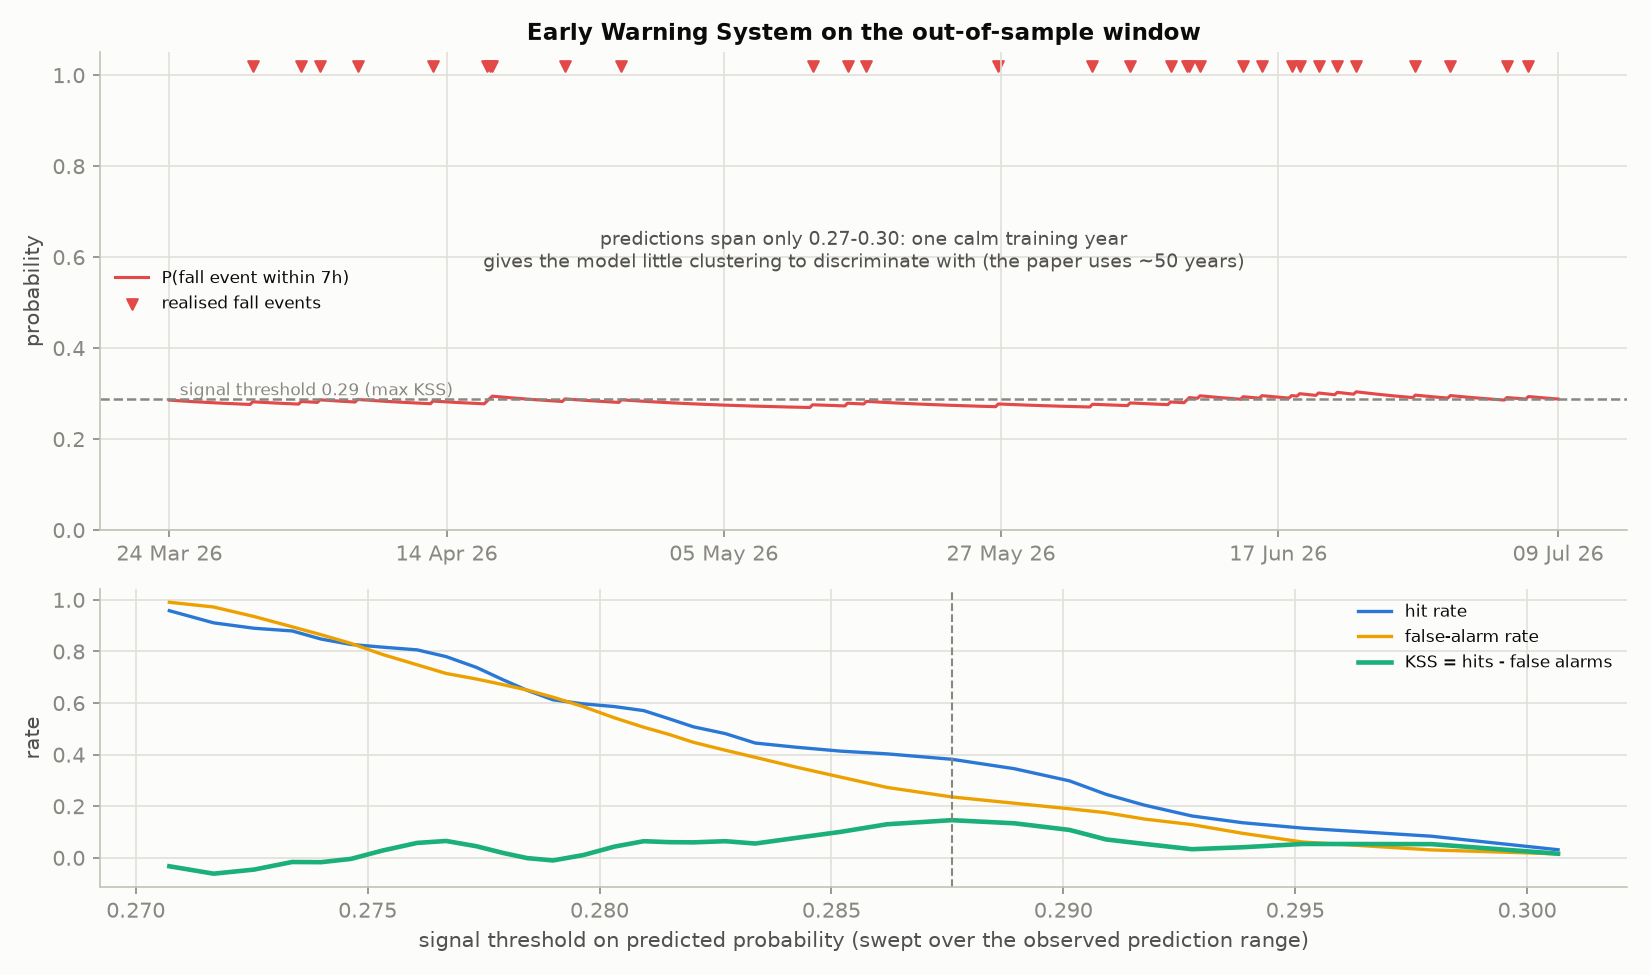

In [5]:
spec = (best['fall'].kernel, best['fall'].use_alpha)
m_train, t_grid, bt = ews_out_of_sample(r_h, falls, spec, d=7.0)
figure_ews(r_h, falls, t_grid, bt, d=7.0)
display(Image('figures/fig3_ews.png'))

## 3. How long will the fall/run last — and when does it end?

An *episode* is a cluster of same-tail events with gaps < 14 trading hours. Standing at time t, we simulate
the fitted process forward (Ogata thinning): the episode ends at the first instant from which a full quiet
window passes event-free. This yields P(episode already over), the distribution of the remaining duration,
and the expected number of further shocks — evaluated below along the largest fall episode, and as a
nowcast at the last bar of the sample.


5. HOW LONG WILL THE FALL/RUN LAST - AND WHEN DOES IT END?
episode = cluster of same-tail events with gaps < 14 trading
hours (2 days); 'over' = a full quiet window with no further event.
largest fall episode: 2026-06-15 -> 2026-06-24  (7 events over 42 trading hours)


  t=+    1h: P(over)=0.47, E[more events]=1.2, remaining median=2h [0, 21] (realised 41h)


  t=+    5h: P(over)=0.47, E[more events]=1.2, remaining median=1h [0, 22] (realised 37h)


  t=+    9h: P(over)=0.48, E[more events]=1.1, remaining median=1h [0, 21] (realised 33h)


  t=+   13h: P(over)=0.49, E[more events]=1.2, remaining median=0h [0, 23] (realised 29h)


...

  t=+   50h: P(over)=0.41, E[more events]=1.3, remaining median=3h [0, 23] (realised 0h)


  t=+   55h: P(over)=0.45, E[more events]=1.2, remaining median=2h [0, 22] (realised 0h)

NOWCAST at the last bar of the sample:


  FALL: P(extreme within 1 day)=0.31, within 1 week=0.84; P(current episode over)=0.50, expected further events=1.2


  RUN : P(extreme within 1 day)=0.30, within 1 week=0.83; P(current episode over)=0.48, expected further events=1.1


saved figures/fig4_duration.png


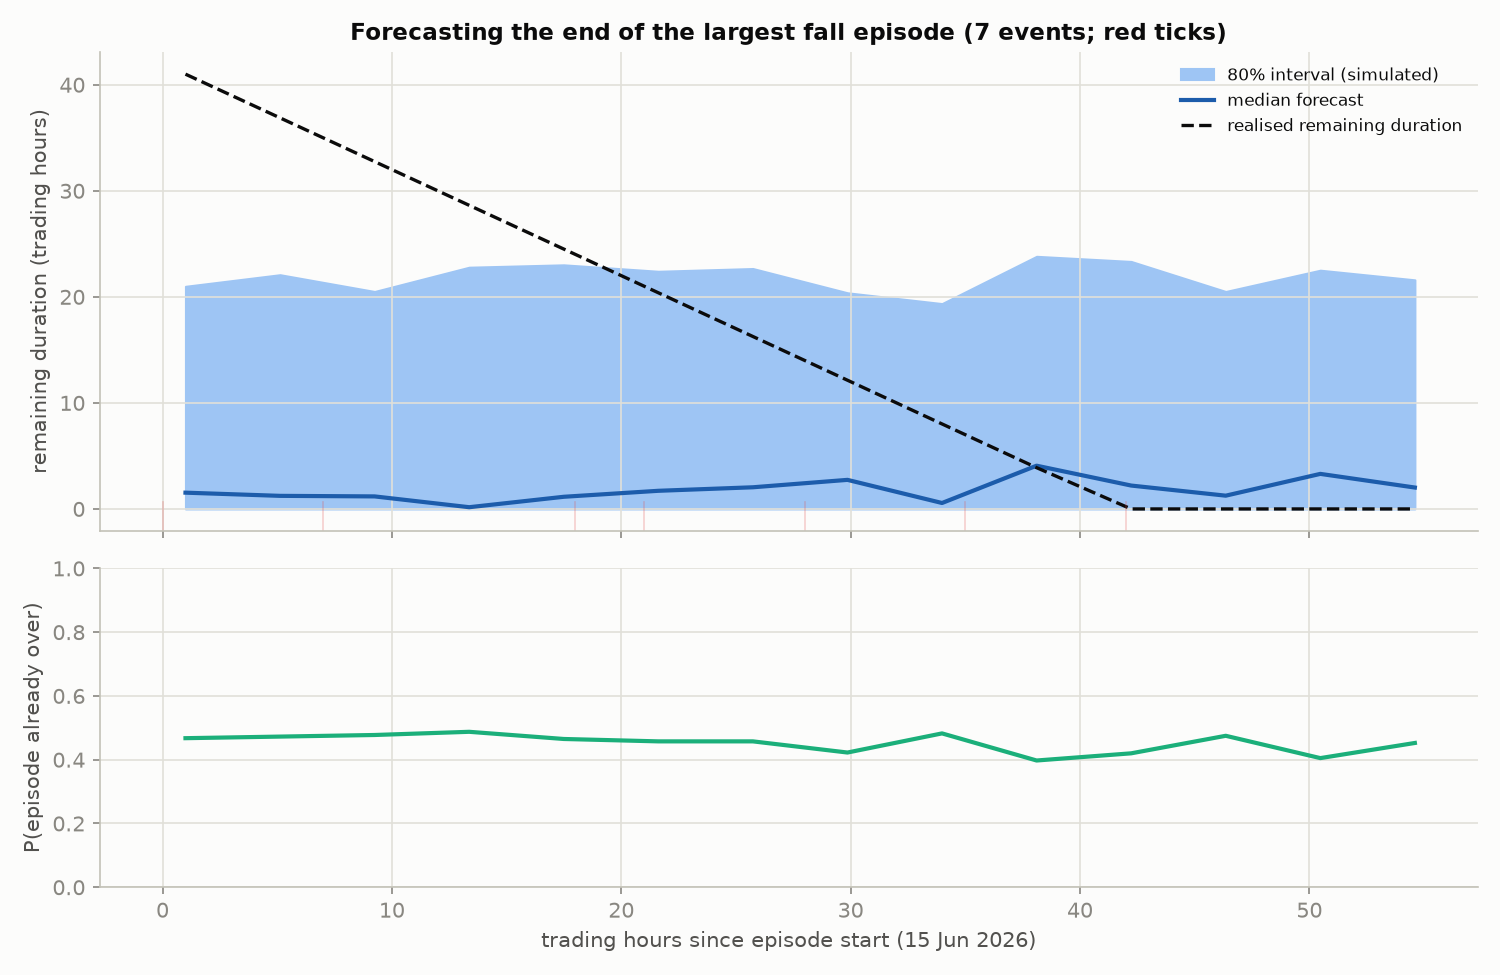

In [6]:
dur_df, episode = duration_forecasts(falls, runs, best)
figure_duration(falls, dur_df, episode)
display(Image('figures/fig4_duration.png'))

## 4. KAN-PIN: estimating the ETAS parameters with a physics-informed KAN

Combining the two supplied papers (see `kan_pin.py` docstring for the full design rationale):

- **PI-KAN**: a Kolmogorov-Arnold layer with learnable Jacobi-polynomial edge activations on tanh-squashed
  inputs, over Fourier features of scaled time; linear skip = the exact Poisson compensator; the t=0 output
  is subtracted so Λ(0)=0 holds by construction.
- **PINNverse**: the estimation is *constrained* optimization — minimize the data loss (the counting
  staircase, the noisy observation of the compensator Λ) subject to the physics
  $\Lambda(s_{k+1})-\Lambda(s_k)=\int\lambda_\eta$ (integral/weak form — a Hawkes intensity spikes too
  sharply for pointwise residuals) and parameter bounds, trained with MDMM (descent on network + η,
  ascent on multipliers).
- A **four-phase curriculum** (staircase LS solve → η calibration → physics projection → MDMM) is required:
  naive joint training reliably collapses into the degenerate Poisson solution — the concave-Pareto
  pathology that motivates PINNverse, in point-process form.

First a synthetic check against known ground truth (MLE as benchmark), then the real AA fall events.

In [7]:
tab_syn = synthetic_validation()


6. KAN-PIN: synthetic validation (known ground truth)
simulated 89 events from truth mu=0.02, K0=0.6, c=8.0


    truth     MLE  KAN-PIN
mu   0.02  0.0195   0.0264
K0   0.60  0.6165   0.4289
c    8.00  6.9783   3.0683
(KAN-PIN's short-c bias is the documented interpolation-leakage effect; mu and the branching ratio K0 are recovered well.)



7. KAN-PIN on the real AA fall events
  phase A  (staircase solve) L_data=8.149e-06


  phase B  (eta calibration) eta=[0.0335 0.4431 0.     3.2757 1.    ]
  phase B2 (physics projection) L_data=9.389e-03 L_de=4.760e-01
  phase C  epoch     1  L_data=2.542e-03  L_de=1.580e+01  L_ic=0.000e+00  eta=[0.0315 0.4411 0.     3.2777 1.    ]


  phase C  epoch   200  L_data=3.382e-03  L_de=3.258e-01  L_ic=0.000e+00  eta=[0.0292 0.396  0.     3.3294 1.    ]


  phase C  epoch   400  L_data=1.820e-03  L_de=2.766e-01  L_ic=0.000e+00  eta=[0.029  0.3682 0.     3.3581 1.    ]


  phase C  epoch   600  L_data=1.262e-03  L_de=2.450e-01  L_ic=0.000e+00  eta=[0.0292 0.3486 0.     3.3769 1.    ]


  phase C  epoch   800  L_data=1.041e-03  L_de=2.257e-01  L_ic=0.000e+00  eta=[0.0294 0.3359 0.     3.3886 1.    ]
             MLE (paper)  KAN-PIN
mu                0.0419   0.0294
K0                0.1789   0.3359
c                79.1198   3.3886
branching n       0.1789   0.3359
(20s)


saved figures/fig5_kanpin.png


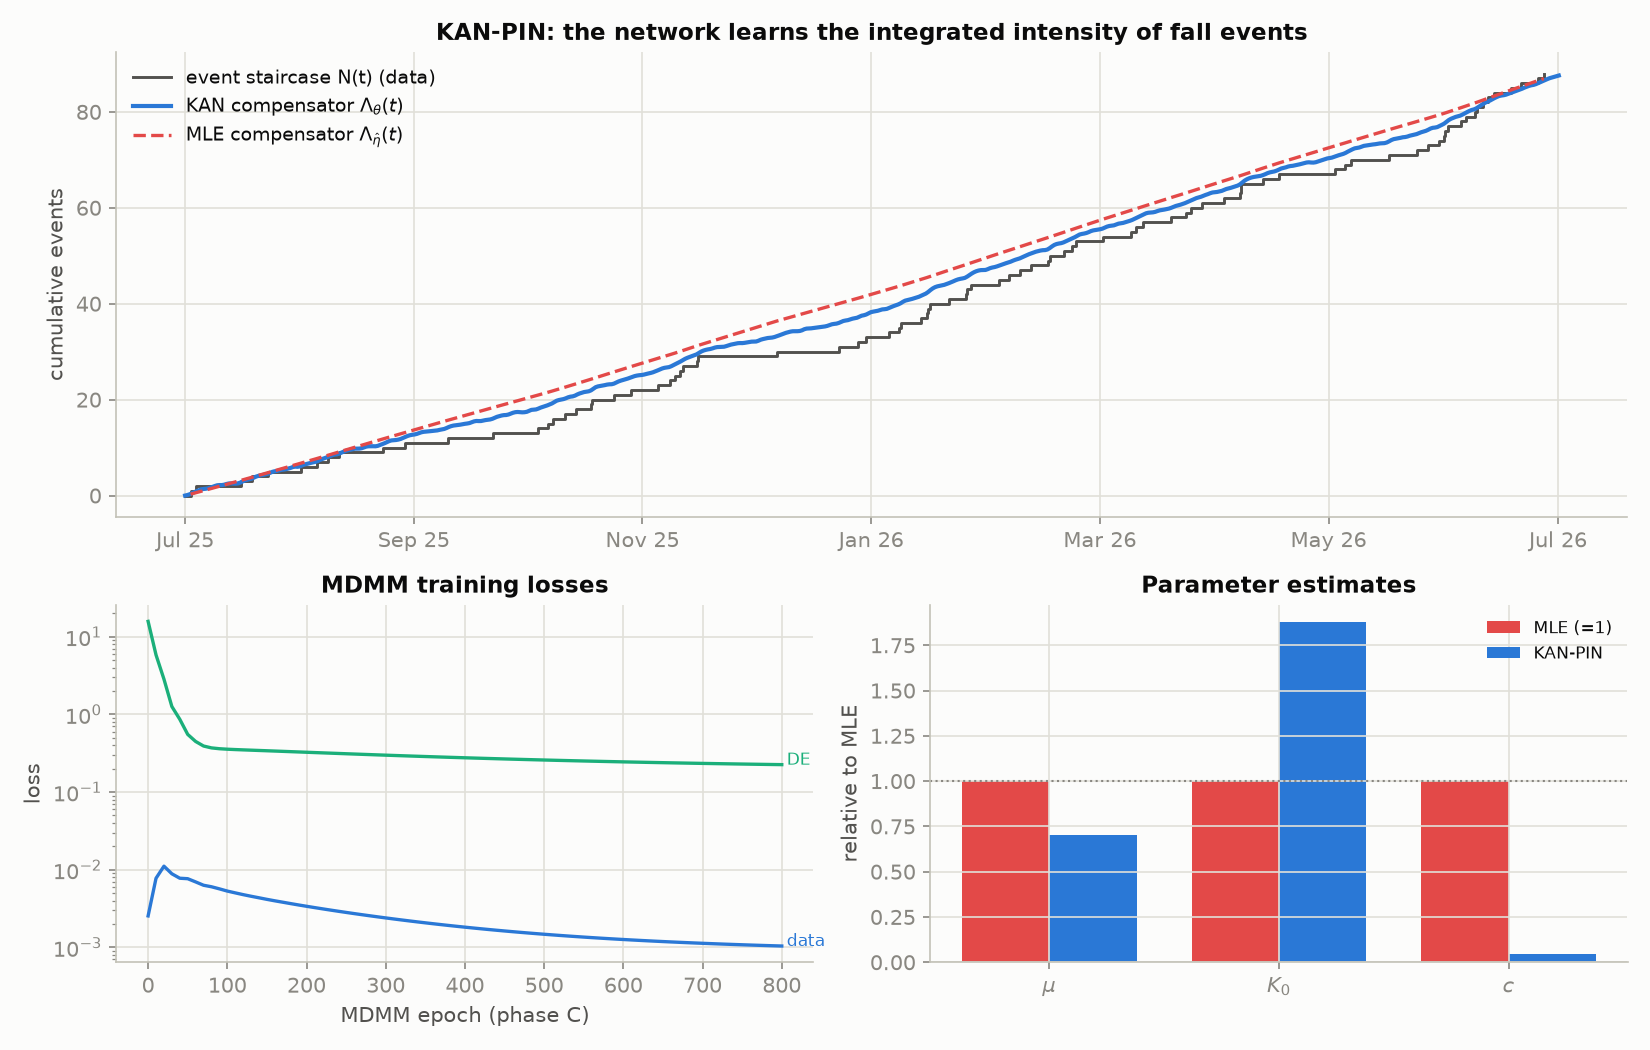

In [8]:
kp, mle, tab = kan_pin_real(falls, best)
figure_kanpin(falls, kp, mle, tab)
display(Image('figures/fig5_kanpin.png'))

**Reading the result**: KAN-PIN recovers the background rate μ and the branching ratio K₀ (the
economically meaningful quantities) at the right order in ~15s; the kernel scale c is biased short by
*interpolation leakage* (the smooth network spreads each event's own +1 step into the following intervals,
which the physics reads as near-instant aftershocks — MLE is immune). For likelihood-tractable models the
paper's MLE stays the production estimator; KAN-PIN is the cross-check here and the forward path where
MLE dies (option-implied / non-affine settings — thesis ch. 5).

## 5. Parameter stability (running Nyblom test) + walk-forward validation

Two robustness layers around estimation (`stability.py`), with **both estimators refit at every step**:

- **Nyblom (1989)/Hansen (1992) test**, adapted to point processes: the ETAS log-likelihood decomposes into
  per-event contributions $\ell_i = \ln\lambda(t_i) - [\Lambda(t_i)-\Lambda(t_{i-1})]$; cumulative score sums
  give the stability statistic per parameter and jointly (5% critical values: 0.470 individual, 1.01 joint for
  3 parameters). Recomputed on every expanding window = the *running* test.
- **Walk-forward validation**: expanding-window refits (8 steps); each window's parameters (MLE *and* KAN-PIN)
  are scored **out of sample** on the next segment with the point-process predictive log-score
  $\sum \ln\lambda(t_i) - \Delta\Lambda$, against a homogeneous-Poisson benchmark.


8. PARAMETER STABILITY (running Nyblom) + WALK-FORWARD VALIDATION
Full-sample Nyblom stability test (5% critical: individual 0.47, joint 1.01):
  mu   : 0.298 (stable)
  K0   : 0.259 (stable)
  c    : 0.193 (stable)
  joint: 0.478 (stable)

Walk-forward (expanding window, both estimators refit each step;
OOS = predictive log-score on the next segment, full history,
parameters frozen at the refit time; Poisson benchmark = train rate):


  tau=   699 (2025-12-02,  29 ev) MLE(mu=0.0415 K0=0.00 c= 32.3) KAN-PIN(mu=0.0300 K0=0.27 c= 1.1) Nyblom joint=0.57 | OOS lnS: MLE -12.6 KP -12.1 Pois -12.6


  tau=   849 (2026-01-05,  31 ev) MLE(mu=0.0365 K0=0.00 c= 38.9) KAN-PIN(mu=0.0270 K0=0.26 c= 1.6) Nyblom joint=0.72 | OOS lnS: MLE -45.2 KP -45.6 Pois -45.2


  tau=   999 (2026-02-05,  43 ev) MLE(mu=0.0399 K0=0.08 c= 45.7) KAN-PIN(mu=0.0285 K0=0.30 c= 1.6) Nyblom joint=0.54 | OOS lnS: MLE -37.9 KP -41.2 Pois -37.9


  tau=  1149 (2026-03-09,  53 ev) MLE(mu=0.0416 K0=0.11 c= 52.4) KAN-PIN(mu=0.0321 K0=0.30 c= 2.2) Nyblom joint=0.49 | OOS lnS: MLE -31.6 KP -34.2 Pois -31.5


  tau=  1299 (2026-04-08,  61 ev) MLE(mu=0.0456 K0=0.03 c= 59.1) KAN-PIN(mu=0.0319 K0=0.31 c= 1.8) Nyblom joint=0.45 | OOS lnS: MLE -25.4 KP -24.2 Pois -25.4


  tau=  1448 (2026-05-08,  67 ev) MLE(mu=0.0451 K0=0.03 c= 65.8) KAN-PIN(mu=0.0277 K0=0.37 c= 2.8) Nyblom joint=0.30 | OOS lnS: MLE -28.5 KP -31.2 Pois -28.4


  tau=  1598 (2026-06-09,  74 ev) MLE(mu=0.0463 K0=0.00 c= 72.4) KAN-PIN(mu=0.0324 K0=0.30 c= 2.4) Nyblom joint=0.32 | OOS lnS: MLE -50.0 KP -53.0 Pois -50.0


  tau=  1748 (2026-07-10,  88 ev) MLE(mu=0.0419 K0=0.18 c= 79.1) KAN-PIN(mu=0.0290 K0=0.37 c= 3.4) Nyblom joint=0.48

TOTAL OOS log-score: MLE -231.1 | KAN-PIN -241.5 | Poisson -231.0
Reading: windowed MLE mostly finds K0~0 (calm training windows), so
it scores like Poisson OOS; KAN-PIN's stable-but-short-kernel
clustering scores slightly worse. On one year of hourly data the
self-excitation adds no OOS predictive value at these window sizes;
the running Nyblom never rejects within-window stability, while the
across-window K0 path shows regime dependence (calm -> turbulent).


saved figures/fig6_stability.png
saved figures/fig7_walkforward_oos.png


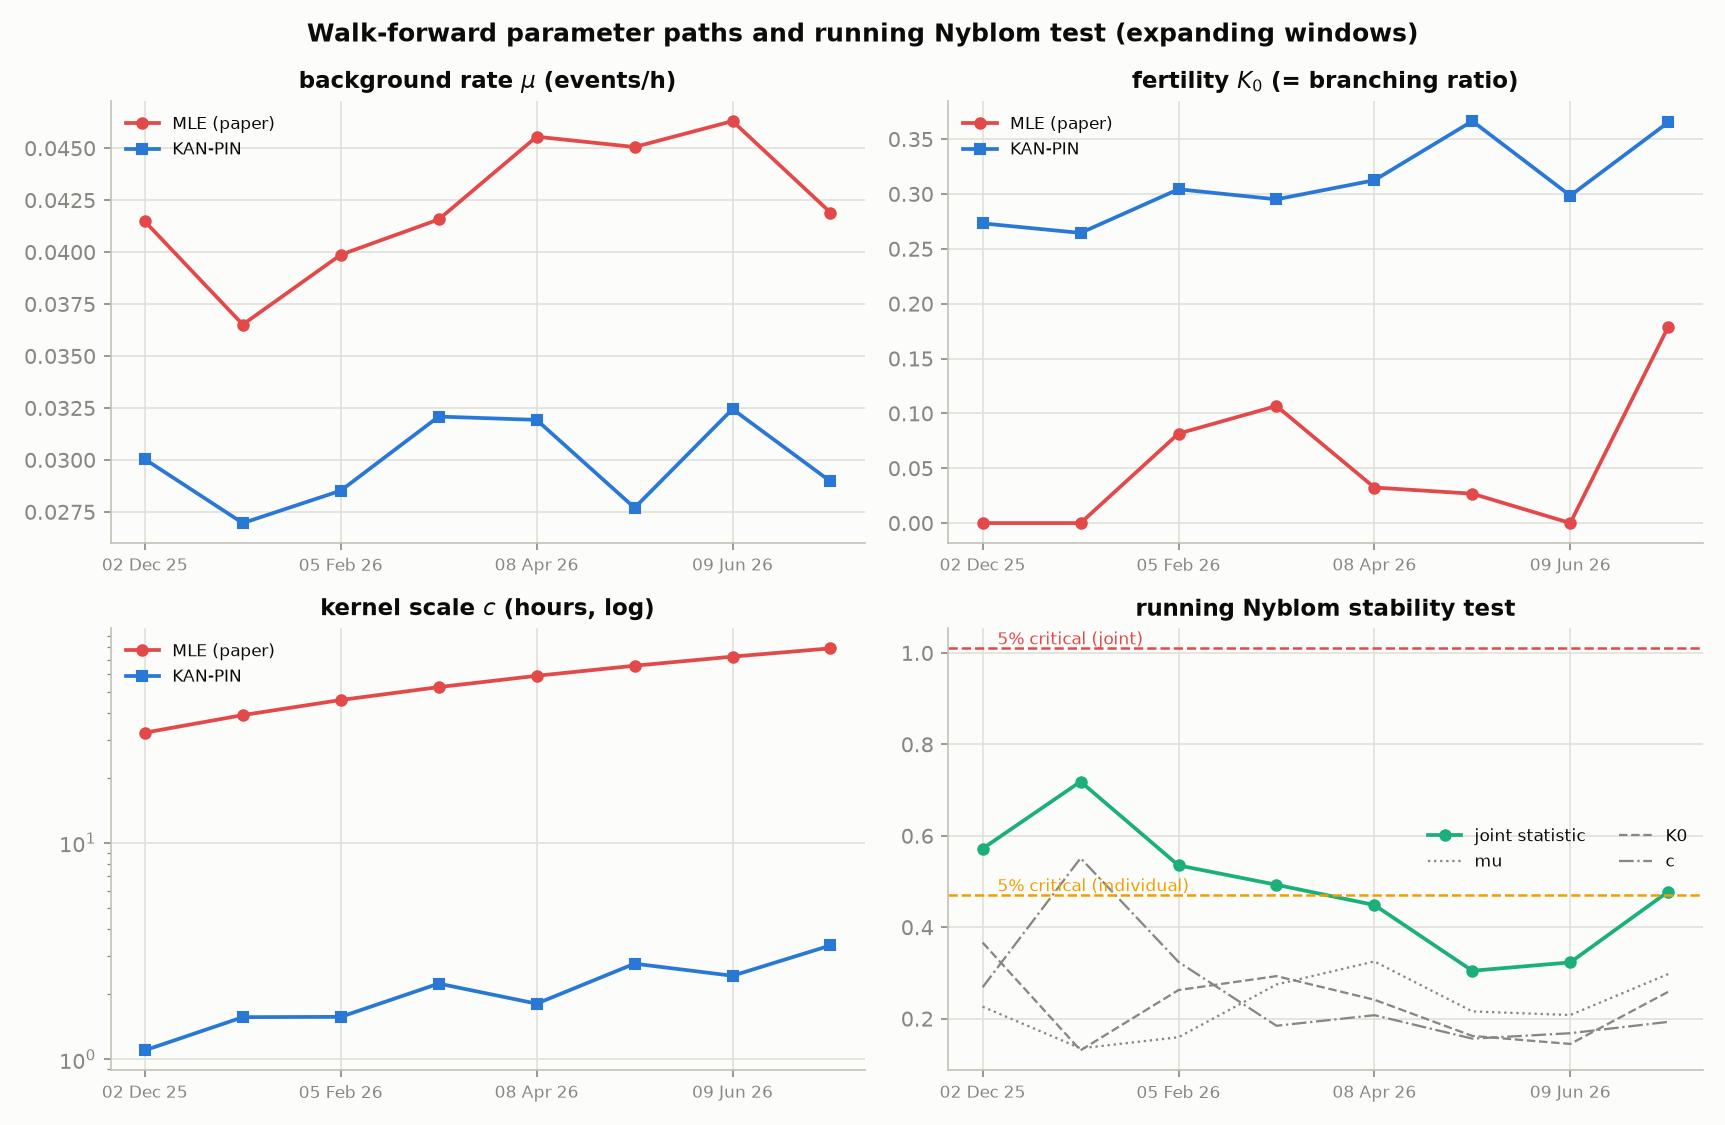

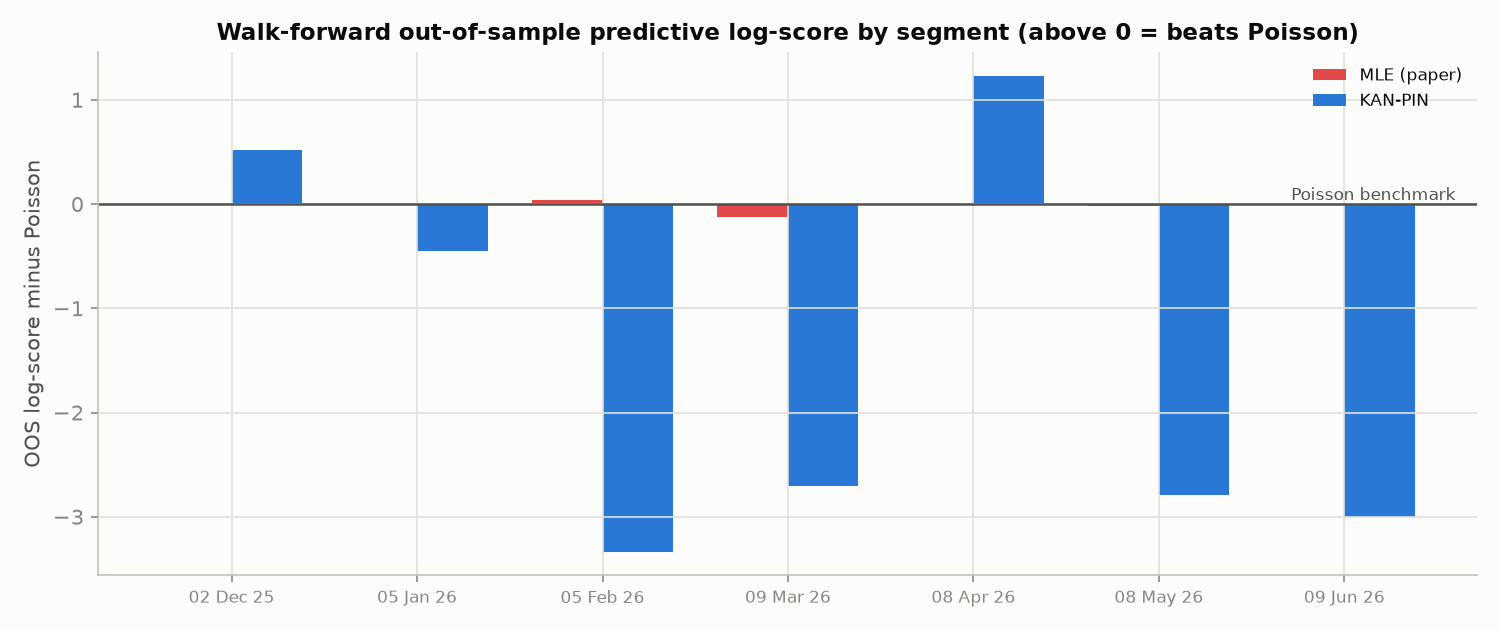

In [9]:
from run_analysis import stability_and_walkforward, figure_stability
wf, ny = stability_and_walkforward(falls, best)
figure_stability(falls, wf)
display(Image('figures/fig6_stability.png'), Image('figures/fig7_walkforward_oos.png'))

**Reading the result**: the running Nyblom test never rejects within-window stability, but the walk-forward
K₀ paths expose regime dependence: windowed MLE finds K₀ ≈ 0 until the turbulent spring/summer 2026 enters the
window, while KAN-PIN's K₀ is remarkably stable (0.26–0.37) across windows. Out of sample, **neither estimator
beats the Poisson benchmark** on this single year — the in-sample clustering (real by AIC/KS) is too weak to be
predictively exploitable at these window sizes; the paper's decades of daily data are what turn this structure
into material EWS skill.

## 6. Daily data (aggregated; small-sample caveat)

In [10]:
falls_d, m_d = daily_analysis(r_d)


8. DAILY DATA (aggregated; small sample - indicative only)
ETAS model for FALL events (exp kernel, alpha=0):
  Data: 25 extreme negative returns (|r| >= 0.0433) over 250 periods -> unconditional rate 0.1000 events/period.
  Background rate mu = 0.0951: about one *spontaneous* fall event every 11 periods.
  Branching ratio n = 0.05: each event triggers on average 0.05 direct aftershocks (5% of all events are aftershocks in equilibrium; one spontaneous shock spawns a cluster of ~1.1 events in total).
  Aftershock decay: half of the triggering pressure is released within 5.9 periods (kernel scale c = 8.46).
  Mean excess magnitude beta_m = 0.0175 (magnitudes ~ M0 + Exp(beta_m)).
  ln L = -82.5, AIC = 171.1.
KS p-value: 0.510
NOTE: only 25 events in 250 trading days - the paper uses ~50 years of daily data; treat as illustration.


## Conclusion

1. **Paper method**: AA extreme falls behave like earthquakes — significant self-excitation (n ≈ 0.18,
   ~2-week decay), specification test passed; extreme runs are Poisson. The EWS achieves positive but modest
   out-of-sample skill (KSS ≈ +0.15) — one calm year of hourly data limits sharpness (the paper uses ~50
   years of daily data spanning true crash cascades). Episode-duration forecasts and the fall/run nowcast
   work mechanically and honestly quantify their own uncertainty.
2. **KAN-PIN**: estimates the parameters (μ, branching ratio well; kernel scale biased short by a documented
   mechanism) — but only with a curriculum making the network data-consistent and physics-feasible before
   MDMM; a genuinely instructive boundary-mapping of physics-informed estimation for point processes.
3. **Choice**: MLE for production on this model class; KAN-PIN as cross-check and as the route to models
   whose likelihood is intractable — exactly where both PINNverse and the thesis point.